In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
paultimothymooney_chest_xray_pneumonia_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1951_bacteria_4882.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg
/kaggle/input/datasets/paultimothymooney

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


CUDA available: True
Device name: Tesla T4


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


(520, 1128, 3)


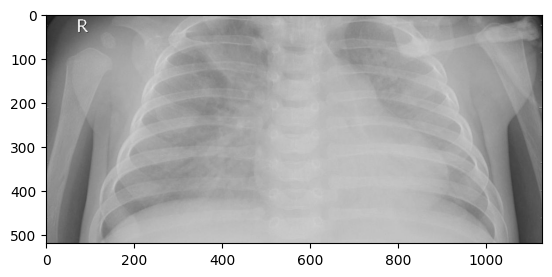

In [ ]:
import cv2
img="/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1011_bacteria_2942.jpeg"
a=cv2.imread(img)
print(a.shape)
plt.imshow(a)

Resize this to 256x256

In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(),          # ensure single channel
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [ ]:
train_dir="/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train"
val_dir="/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val"
test_dir="/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test"

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader

train_data = datasets.ImageFolder(train_dir, transform=transform)
val_data   = datasets.ImageFolder(val_dir, transform=transform)
test_data  = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=16, shuffle=False)


In [ ]:
print(train_data.classes)   # should print ['NORMAL', 'PNEUMONIA']
print(train_data.class_to_idx)  # {'NORMAL':0, 'PNEUMONIA':1}


['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}


# Autoencoder Architecture


In [ ]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(),  # (i/p channel, o/p channel(feature maps),kernel size) 256x256 becomes 128x128 with 32 channels
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU() # 128 o/p channels but size 32x32 now
        )
        #256x256x1 to 32x32x128 (much smaller but rich in features)
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1), nn.Tanh()
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
model = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for imgs, _ in train_loader:
        noisy_imgs = imgs + 0.1*torch.randn_like(imgs)
        noisy_imgs, imgs = noisy_imgs.to(device), imgs.to(device)

        outputs = model(noisy_imgs)
        loss = criterion(outputs, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}")

    # 🔑 Save latest checkpoint after each epoch
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss,
    }, "latest_checkpoint.pth")


Epoch [1/10], Loss: 0.012116
Epoch [2/10], Loss: 0.002501
Epoch [3/10], Loss: 0.001967
Epoch [4/10], Loss: 0.001723
Epoch [5/10], Loss: 0.001558
Epoch [6/10], Loss: 0.001477
Epoch [7/10], Loss: 0.001408
Epoch [8/10], Loss: 0.001357
Epoch [9/10], Loss: 0.001308
Epoch [10/10], Loss: 0.001281


Quantitative metrics:


In [ ]:
# Save only the model weights
torch.save(model.state_dict(), "autoencoder_weights.pth")


Compute reconstruction errors

In [ ]:
import torch.nn.functional as F
import numpy as np

errors_normal, errors_pneumonia = [], []

with torch.no_grad():
    for imgs, labels in test_loader:  # assume labels: 0 = NORMAL, 1 = PNEUMONIA
        noisy_imgs = imgs + 0.1*torch.randn_like(imgs)
        noisy_imgs, imgs = noisy_imgs.to(device), imgs.to(device)

        outputs = model(noisy_imgs)
        batch_errors = F.mse_loss(outputs, imgs, reduction='none')
        batch_errors = batch_errors.view(batch_errors.size(0), -1).mean(dim=1).cpu().numpy()

        for err, lbl in zip(batch_errors, labels.numpy()):
            if lbl == 0:
                errors_normal.append(err)
            else:
                errors_pneumonia.append(err)

print("Avg Normal Error:", np.mean(errors_normal))
print("Avg Pneumonia Error:", np.mean(errors_pneumonia))


Avg Normal Error: 0.0013722538
Avg Pneumonia Error: 0.0011686119


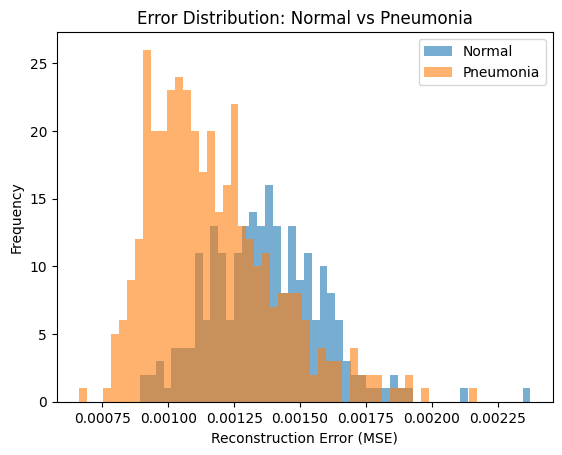

In [ ]:
import matplotlib.pyplot as plt

plt.hist(errors_normal, bins=50, alpha=0.6, label="Normal")
plt.hist(errors_pneumonia, bins=50, alpha=0.6, label="Pneumonia")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Frequency")
plt.legend()
plt.title("Error Distribution: Normal vs Pneumonia")
plt.show()


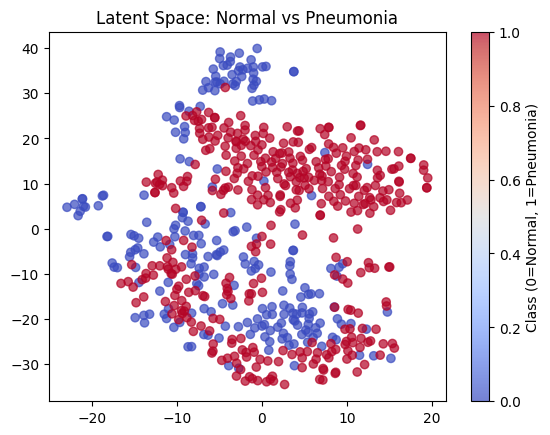

In [ ]:
from sklearn.manifold import TSNE

latent_vectors, labels_all = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        noisy_imgs = imgs + 0.1*torch.randn_like(imgs)
        noisy_imgs = noisy_imgs.to(device)

        # Extract latent features (encoder output)
        latent = model.encoder(noisy_imgs)
        latent = latent.view(latent.size(0), -1).cpu().numpy()

        latent_vectors.append(latent)
        labels_all.extend(labels.numpy())

latent_vectors = np.concatenate(latent_vectors, axis=0)

# Reduce to 2D with t-SNE
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors)

plt.scatter(latent_2d[:,0], latent_2d[:,1], c=labels_all, cmap="coolwarm", alpha=0.7)
plt.title("Latent Space: Normal vs Pneumonia")
plt.colorbar(label="Class (0=Normal, 1=Pneumonia)")
plt.show()


Normal Avg Error: 0.0013733733
Pneumonia Avg Error: 0.0011668738
Normal Avg PSNR: 28.674509956326144
Pneumonia Avg PSNR: 29.413405459105753
Normal Avg SSIM: 0.9071668416104314
Pneumonia Avg SSIM: 0.9091534719425131


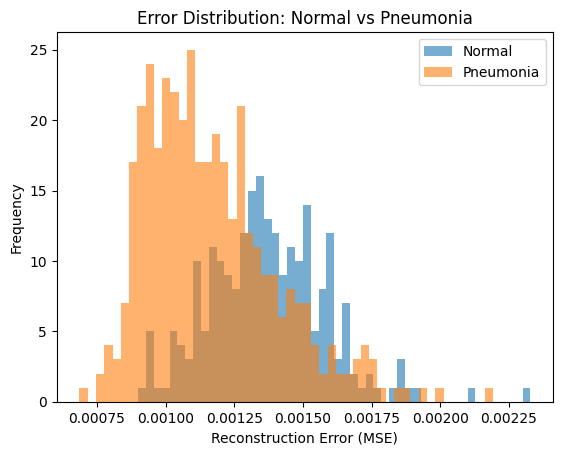

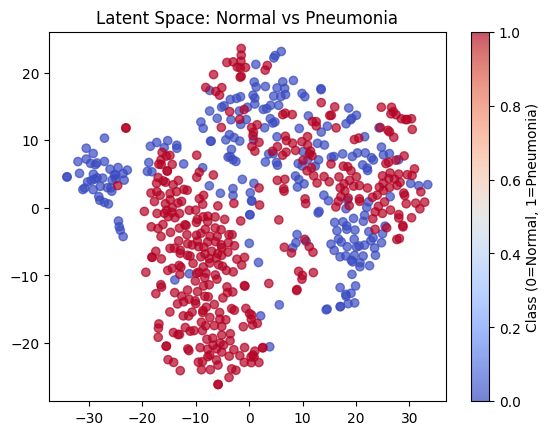

In [ ]:
import torch
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from sklearn.manifold import TSNE

# --- Load checkpoint properly ---
checkpoint = torch.load("/kaggle/working/latest_checkpoint.pth", map_location=device)

model = DenoisingAutoencoder().to(device)
model.load_state_dict(checkpoint['model_state_dict'])   # ✅ only weights
model.eval()

# If you want to resume training later:
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# start_epoch = checkpoint['epoch']

# --- Helper functions ---
def psnr(img1, img2):
    mse = F.mse_loss(img1, img2).item()
    if mse == 0:
        return float('inf')
    max_pixel = 1.0  # assuming images normalized [0,1]
    return 20 * math.log10(max_pixel / math.sqrt(mse))

# --- Collect metrics ---
errors_normal, errors_pneumonia = [], []
psnr_normal, psnr_pneumonia = [], []
ssim_normal, ssim_pneumonia = [], []

latent_vectors, labels_all = [], []

with torch.no_grad():
    for imgs, labels in test_loader:  # labels: 0 = NORMAL, 1 = PNEUMONIA
        noisy_imgs = imgs + 0.1*torch.randn_like(imgs)
        noisy_imgs, imgs = noisy_imgs.to(device), imgs.to(device)

        outputs = model(noisy_imgs)

        # Reconstruction error (MSE per image)
        batch_errors = F.mse_loss(outputs, imgs, reduction='none')
        batch_errors = batch_errors.view(batch_errors.size(0), -1).mean(dim=1).cpu().numpy()

        for i in range(len(labels)):
            orig = imgs[i].cpu().numpy().squeeze()
            recon = outputs[i].cpu().numpy().squeeze()

            ssim_val = ssim(orig, recon, data_range=orig.max() - orig.min())
            psnr_val = psnr(outputs[i], imgs[i])

            if labels[i].item() == 0:  # NORMAL
                errors_normal.append(batch_errors[i])
                psnr_normal.append(psnr_val)
                ssim_normal.append(ssim_val)
            else:  # PNEUMONIA
                errors_pneumonia.append(batch_errors[i])
                psnr_pneumonia.append(psnr_val)
                ssim_pneumonia.append(ssim_val)

        # Latent space features
        latent = model.encoder(noisy_imgs)
        latent = latent.view(latent.size(0), -1).cpu().numpy()
        latent_vectors.append(latent)
        labels_all.extend(labels.numpy())

latent_vectors = np.concatenate(latent_vectors, axis=0)

# --- Print averages ---
print("Normal Avg Error:", np.mean(errors_normal))
print("Pneumonia Avg Error:", np.mean(errors_pneumonia))
print("Normal Avg PSNR:", np.mean(psnr_normal))
print("Pneumonia Avg PSNR:", np.mean(psnr_pneumonia))
print("Normal Avg SSIM:", np.mean(ssim_normal))
print("Pneumonia Avg SSIM:", np.mean(ssim_pneumonia))

# --- Plot error distributions ---
plt.hist(errors_normal, bins=50, alpha=0.6, label="Normal")
plt.hist(errors_pneumonia, bins=50, alpha=0.6, label="Pneumonia")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Frequency")
plt.legend()
plt.title("Error Distribution: Normal vs Pneumonia")
plt.show()

# --- Latent space visualization ---
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors)

plt.scatter(latent_2d[:,0], latent_2d[:,1], c=labels_all, cmap="coolwarm", alpha=0.7)
plt.title("Latent Space: Normal vs Pneumonia")
plt.colorbar(label="Class (0=Normal, 1=Pneumonia)")
plt.show()


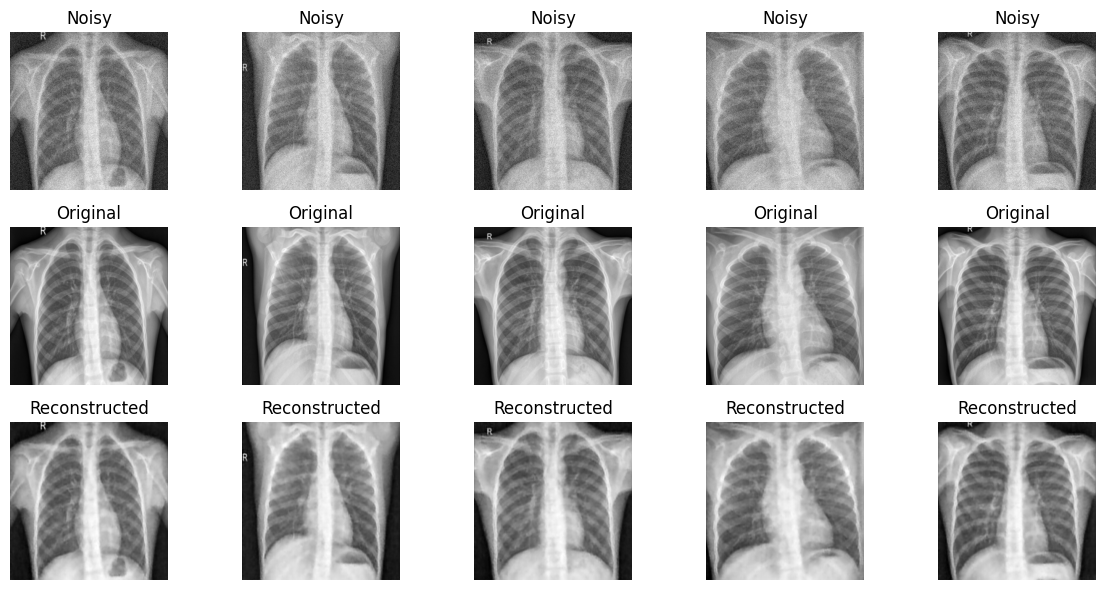

In [ ]:
import matplotlib.pyplot as plt

model.eval()
examples = iter(test_loader)
imgs, labels = next(examples)

noisy_imgs = imgs + 0.1*torch.randn_like(imgs)
noisy_imgs, imgs = noisy_imgs.to(device), imgs.to(device)

with torch.no_grad():
    outputs = model(noisy_imgs)

# Plot first 5 examples
n = 5
plt.figure(figsize=(12,6))
for i in range(n):
    plt.subplot(3, n, i+1)
    plt.imshow(noisy_imgs[i].cpu().squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3, n, i+1+n)
    plt.imshow(imgs[i].cpu().squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3, n, i+1+2*n)
    plt.imshow(outputs[i].cpu().squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()


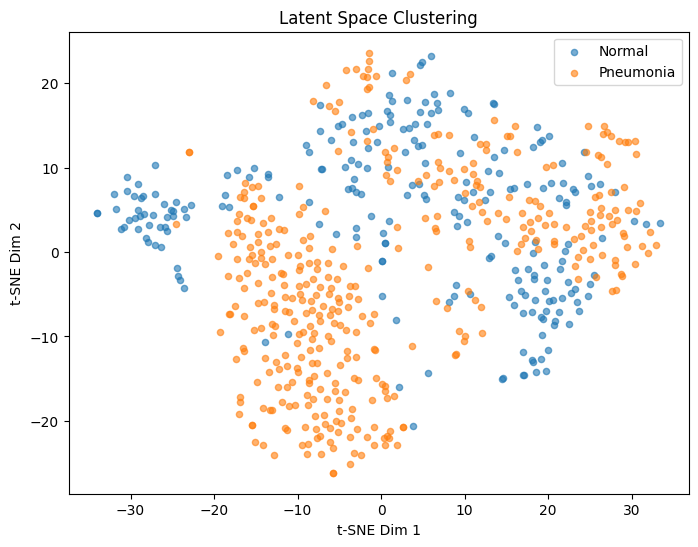

In [ ]:
plt.figure(figsize=(8,6))
for lbl in [0,1]:
    mask = np.array(labels_all) == lbl
    plt.scatter(latent_2d[mask,0], latent_2d[mask,1],
                label="Normal" if lbl==0 else "Pneumonia",
                alpha=0.6, s=20)
plt.legend()
plt.title("Latent Space Clustering")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.savefig("/kaggle/working/latent_space.png", dpi=300)
plt.show()
